### This notebook computes "P1. SPI intensity and frequency (Standarized Precipitation Index)" indicator for the 27 basins of IKI Project

**Created:** 1//12/2026 by Sophia Bakar (sbakar@rti.org)

**Project #:** 0219481  

**Last modified:** 1/15/2026 by Sophia

**Status:** Complete and loaded into the sql database for the baseline and first future scenario.

**QA Status:** reviewed by Jorge Mayo (jmayo@rti.org) on 1/29/2026  

**Original Script Stored at:** Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\Peligro
 
**Objective:**   

**Compatibility:** 

**Packages:** numpy, pandas, geopandas, sqlite3, matplotlib 
.  
**Further documentation:**  
 
**Inputs:**   

**Outputs:** 
 
**Assumptions:** The annex does not provide guidance for how to classify the frequency of drought months. We use the quartile-based classification approach which is used in P2 to classify the frequency values. This approach needs QC. Also in the pilot the compute the SPI at a grid level, directly from PISCO netcdf, we are using the MAP to do so.
 
**Future work:** 
 
**Notes:** We should be able to use the output from waterALLOC for this, but for now we are calculating SPI by querying the met tables from the modeling grupos databases. 

In [ ]:
## Steps for QC
# Verify that the first code cells follow this structure
# 1) import libraries
# 2) set up user and database path (this will eventually change based on how we set up the repo/distribute the input data)
# 3) set up indicator ID and get scenarios from the database - for now we are just populating the database for scenarios 1 and 2, but there should be commented lines to get all available scenarios from the database
# 4) define filepaths for input data (again this will eventually change so for now we want all the filepaths in one block to change later)

# Then verify that the rest of the code performs the intended calculations and outputs the expected results. You can run up until the sql insert which is the last three cells in the notebook.
# Make sure the code to perform the calculations is well-organized and commented for clarity.
# Add notes about the methodology, assumptions, and anything that sticks out about the results in the markdown block at the top of the page.
# Add any notes about NaN/0 handling in the markdown block under notes or assumptions
# Add a section in the markdown "QA performed by:" so that we know who checked and when 

In [10]:
import numpy as np
import pandas as pd
import sqlite3
import geopandas as gpd
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import gamma, norm

In [2]:
# set up user and database path
user = 'jmayo'
#user = 'sbakar'
#db_path = fr'C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db'
db_path = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db"

In [3]:
# set up indicator ID and get scenarios from database
IndID = 101 #Indicator ID (Peligro = 1 + 0X where X is the Peligro Indicator number) 

# get scenarios from database 
conn = sqlite3.connect(db_path)

scenarios_df = pd.read_sql_query(
    """
    SELECT ScnID, ScnName
    FROM ScnMod
    """,
    conn
)

conn.close()

# For now: apply the same values to all scenarios
scenario_ids = scenarios_df['ScnID'].tolist()

In [4]:
scenario_ids

[1, 2]

In [5]:
# define filepaths for input data
#subbasins_shapefile = fr"C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\AI2b_Modelacion\Grupos_Modelacion\GIS_WaterALLOC_General\Peru_AHD_with_districts.shp"
subbasins_shapefile = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2b_Modelacion\Grupos_Modelacion\GIS_WaterALLOC_General\Peru_AHD_with_districts.shp"

In [6]:
# read in input data
subbasins_gdf = gpd.read_file(subbasins_shapefile).set_index('COMID').to_crs('WGS84')

In [7]:
# function to query the modeling groups databases for daily precipitation
def get_precipitation(scenarios):

    dfs = []

    for grupo in range(1,13):
        
        #sqlite_path = f'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/Grupo_{grupo}/BD/BD_Grupo_{grupo}.sqlite'
        sqlite_path = f"C:/Users/sbakar/OneDrive - Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/Grupo_{grupo}/BD/BD_Grupo_{grupo}.sqlite"

        with sqlite3.connect(sqlite_path) as conn:
            for ScnID, scn_info in scenarios.items():

                query = """
                SELECT
                    comid,
                    avg_precip_cm,
                    measured_date
                FROM catchment_met_observations
                WHERE met_source_id = ?;
                """

                met = pd.read_sql_query(
                    query,
                    conn,
                    params=(scn_info['met_source_id'],)
                )

                if met.empty:
                    continue

                met['measured_date'] = pd.to_datetime(met['measured_date'], format='%Y-%m-%d %H:%M:%S %z UTC', errors='coerce' )

                met = met.dropna(subset=['measured_date'])

                # add scenario ID
                met['ScnID'] = ScnID

                dfs.append(met)

    if not dfs:
        return pd.DataFrame(columns=['ScnID', 'comid', 'measured_date', 'avg_precip_cm'])

    df = pd.concat(dfs, ignore_index=True)

    return df[['ScnID', 'comid', 'measured_date', 'avg_precip_cm']]

In [8]:
# define mapping for scenarios and met source IDs in the modeling groups table 
scenarios = {
    1: {"met_source_id": 2},  # Baseline
    2: {"met_source_id": 5},  # Future CMIP6 8.5
}

In [9]:
# get precipitation from the modeling groups database 
precip_df = get_precipitation(scenarios)

In [11]:
# set up precipitation dataframe for SPI calculation
# convert precip from cm to mm
precip_df['avg_precip_mm'] = precip_df['avg_precip_cm'] * 10
precip_df['measured_date'] = pd.to_datetime(precip_df['measured_date'],errors='coerce',utc=True)

# convert daily precip to monthly
precip_df['year_month'] = precip_df['measured_date'].dt.to_period('M')  # e.g., 1981-01

monthly_precip = (precip_df.groupby(['ScnID', 'comid', 'year_month'])['avg_precip_mm'].sum().reset_index())

# convert year_month back to datetime for plotting
monthly_precip['month_start'] = monthly_precip['year_month'].dt.to_timestamp()

C:\Users\sbakar\AppData\Local\Temp\ipykernel_35424\356084222.py:7: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  precip_df['year_month'] = precip_df['measured_date'].dt.to_period('M')  # e.g., 1981-01


In [12]:
def calculate_spi(precip_series, window):
    rolling = precip_series.rolling(window=window, min_periods=window).sum()
    rolling_valid = rolling.dropna()

    # Separate zero and non-zero precipitation
    non_zero = rolling_valid[rolling_valid > 0]
    q = 1 - len(non_zero) / len(rolling_valid)

    # Fit gamma to non-zero values
    shape, loc, scale_param = gamma.fit(non_zero, floc=0)

    # Gamma CDF for all values
    cdf_gamma = gamma.cdf(rolling, shape, loc=0, scale=scale_param)

    # Mixed distribution
    cdf = q + (1 - q) * cdf_gamma
    cdf = np.clip(cdf, 1e-6, 1 - 1e-6)

    spi = norm.ppf(cdf)
    return pd.Series(spi, index=precip_series.index)

In [13]:
def calculate_spi_for_group(group, window):
    group = group.sort_values('month_start').copy()
    group[f'SPI_{window}'] = calculate_spi(group['avg_precip_mm'], window)
    return group

In [14]:
def compute_spi_n(df, window):
    return (df.groupby(['ScnID', 'comid'], group_keys=False).apply(calculate_spi_for_group, window=window))

In [15]:
spi_1 = compute_spi_n(monthly_precip, window=1)
spi_3 = compute_spi_n(monthly_precip, window=3)
spi_12 = compute_spi_n(monthly_precip, window=12)

C:\Users\sbakar\AppData\Local\Temp\ipykernel_35424\2869961981.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return (df.groupby(['ScnID', 'comid'], group_keys=False).apply(calculate_spi_for_group, window=window))
C:\Users\sbakar\AppData\Local\Temp\ipykernel_35424\2869961981.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return (df.groupby(['ScnID', 'comid'], group_keys=False).apply(calculate_spi_f

In [16]:
spi_3['month'] = spi_3['month_start'].dt.month
# quedarse solo con febrero
spi_3_def = spi_3[spi_3['month'] == 2].copy()

In [17]:
spi_12['month'] = spi_12['month_start'].dt.month
# quedarse solo con agosto
spi_12_hydro = spi_12[spi_12['month'] == 8].copy()

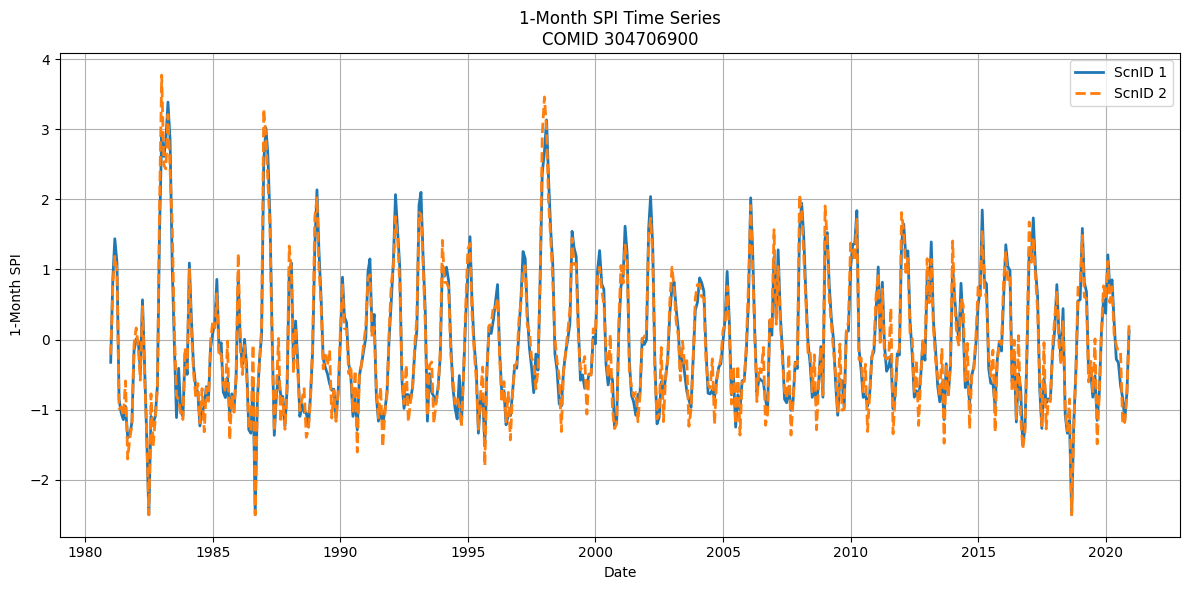

In [18]:
# time series plot for QC

# test COMID
test_comid = '304706900'

# filter SPI data for the test COMID and ScnIDs 1 and 2
spi_comid = spi_1[
    (spi_1['comid'].astype(str) == test_comid) &
    (spi_1['ScnID'].isin([1, 2]))
].sort_values('month_start')

# create the plot
plt.figure(figsize=(12, 6))

# loop over the scenarios for plotting
for scn_id, group in spi_comid.groupby('ScnID'):
    plt.plot(
        group['month_start'],
        group['SPI_1'],
        label=f'ScnID {scn_id}',
        linewidth=2,
        linestyle='-' if scn_id == 1 else '--'
    )

plt.xlabel('Date')
plt.ylabel('1-Month SPI')
plt.title(f'1-Month SPI Time Series\nCOMID {test_comid}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

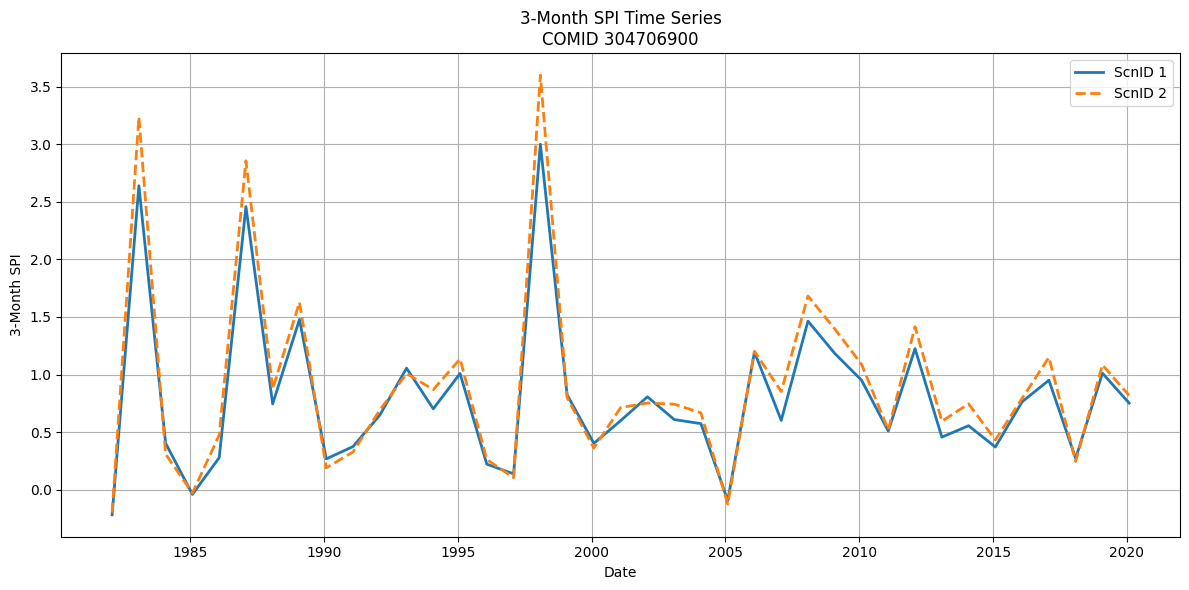

In [19]:
# time series plot for QC

# test COMID
test_comid = '304706900'

# filter SPI data for the test COMID and ScnIDs 1 and 2
spi_comid = spi_3_def[
    (spi_3_def['comid'].astype(str) == test_comid) &
    (spi_3_def['ScnID'].isin([1, 2]))
].sort_values('month_start')

# create the plot
plt.figure(figsize=(12, 6))

# loop over the scenarios for plotting
for scn_id, group in spi_comid.groupby('ScnID'):
    plt.plot(
        group['month_start'],
        group['SPI_3'],
        label=f'ScnID {scn_id}',
        linewidth=2,
        linestyle='-' if scn_id == 1 else '--'
    )

plt.xlabel('Date')
plt.ylabel('3-Month SPI')
plt.title(f'3-Month SPI Time Series\nCOMID {test_comid}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

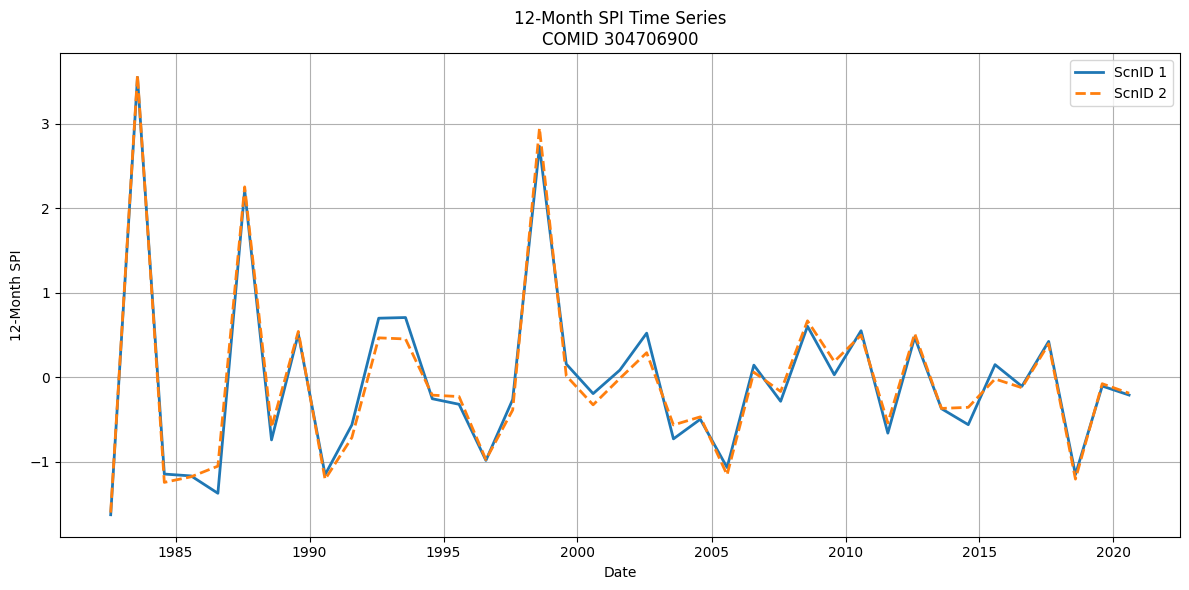

In [20]:
# time series plot for QC

# test COMID
test_comid = '304706900'

# filter SPI data for the test COMID and ScnIDs 1 and 2
spi_comid = spi_12_hydro[
    (spi_12_hydro['comid'].astype(str) == test_comid) &
    (spi_12_hydro['ScnID'].isin([1, 2]))
].sort_values('month_start')

# create the plot
plt.figure(figsize=(12, 6))

# loop over the scenarios for plotting
for scn_id, group in spi_comid.groupby('ScnID'):
    plt.plot(
        group['month_start'],
        group['SPI_12'],
        label=f'ScnID {scn_id}',
        linewidth=2,
        linestyle='-' if scn_id == 1 else '--'
    )

plt.xlabel('Date')
plt.ylabel('12-Month SPI')
plt.title(f'12-Month SPI Time Series\nCOMID {test_comid}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

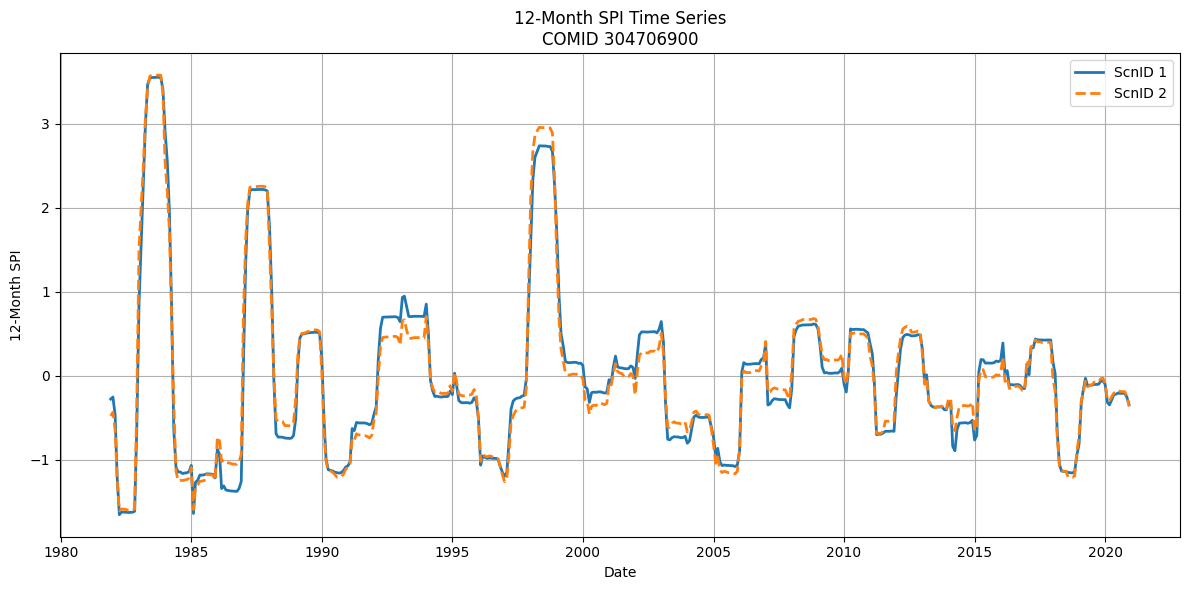

In [21]:
# time series plot for QC

# test COMID
test_comid = '304706900'

# filter SPI data for the test COMID and ScnIDs 1 and 2
spi_comid = spi_12[
    (spi_12['comid'].astype(str) == test_comid) &
    (spi_12['ScnID'].isin([1, 2]))
].sort_values('month_start')

# create the plot
plt.figure(figsize=(12, 6))

# loop over the scenarios for plotting
for scn_id, group in spi_comid.groupby('ScnID'):
    plt.plot(
        group['month_start'],
        group['SPI_12'],
        label=f'ScnID {scn_id}',
        linewidth=2,
        linestyle='-' if scn_id == 1 else '--'
    )

plt.xlabel('Date')
plt.ylabel('12-Month SPI')
plt.title(f'12-Month SPI Time Series\nCOMID {test_comid}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [22]:
def classify_spi_intensity(spi):
    if spi < -2.0:
        return 4  # extremadamente seco
    elif spi < -1.5:
        return 3  # severamente seco
    elif spi < -1.0:
        return 2  # moderadamente seco
    else:
        return 1  # sin sequía o normal (leve)

In [23]:
# apply intensity classification to each set of SPI values
intensity_1 = (spi_1.groupby(['ScnID', 'comid'])['SPI_1'].min().reset_index(name='SPI_min'))
intensity_1['Intensity_class'] = (intensity_1['SPI_min'].apply(classify_spi_intensity))

intensity_3 = (spi_3_def.groupby(['ScnID', 'comid'])['SPI_3'].min().reset_index(name='SPI_min'))
intensity_3['Intensity_class'] = (intensity_3['SPI_min'].apply(classify_spi_intensity))

intensity_12 = (spi_12_hydro.groupby(['ScnID', 'comid'])['SPI_12'].min().reset_index(name='SPI_min'))
intensity_12['Intensity_class'] = (intensity_12['SPI_min'].apply(classify_spi_intensity))

In [25]:
# Define drought event threshold (SPI <= -1 means drought)
drought_threshold = -1.0

spi_1["Drought_event"] = (spi_1["SPI_1"] <= drought_threshold).astype(int)
spi_3_def["Drought_event"] = (spi_3_def["SPI_3"] <= drought_threshold).astype(int)
spi_12_hydro["Drought_event"] = (spi_12_hydro["SPI_12"] <= drought_threshold).astype(int)

In [26]:
# apply frecuency calculation to each set of SPI values using the frequency ratio approach
freq_1 = (spi_1.groupby(['ScnID', 'comid'])['Drought_event'].mean().reset_index(name='Frequency_ratio'))

freq_3 = (spi_3_def.groupby(['ScnID', 'comid'])['Drought_event'].mean().reset_index(name='Frequency_ratio'))

freq_12 = (spi_12_hydro.groupby(['ScnID', 'comid'])['Drought_event'].mean().reset_index(name='Frequency_ratio'))

In [27]:
# Classify frequency ratio into hazard categories
# (physical/interpretative thresholds)
def classify_frequency_ratio(fr):
    if fr >= 0.40:
        return 4  # Muy Alta (≥ 40% del tiempo)
    elif fr >= 0.25:
        return 3  # Alta
    elif fr >= 0.10:
        return 2  # Media
    else:
        return 1  # Baja

In [28]:
# classify the frequency ratio values into hazard categories
freq_1['Frequency_class'] = freq_1['Frequency_ratio'].apply(classify_frequency_ratio)
freq_3['Frequency_class'] = freq_3['Frequency_ratio'].apply(classify_frequency_ratio)
freq_12['Frequency_class'] = freq_12['Frequency_ratio'].apply(classify_frequency_ratio)

In [29]:
# Merge frequency info back with intensity data
hazard_base_1 = freq_1.merge(intensity_1,on=['ScnID', 'comid'],how='left')
hazard_base_3 = freq_3.merge(intensity_3,on=['ScnID', 'comid'],how='left')
hazard_base_12 = freq_12.merge(intensity_12,on=['ScnID', 'comid'],how='left')

In [30]:
# set up hazard mapping to get final indicator value combining frequency and intensity
hazard_matrix = {
    4: {1: "Medio", 2: "Alto", 3: "Muy alto", 4: "Muy alto"},
    3: {1: "Medio",  2: "Alto", 3: "Alto",     4: "Muy alto"},
    2: {1: "Bajo",  2: "Medio",  3: "Alto",    4: "Alto"},
    1: {1: "Bajo",  2: "Bajo",  3: "Medio",    4: "Medio"},
}

hazard_to_val = {
    "Bajo": 1,
    "Medio": 2,
    "Alto": 3,
    "Muy alto": 4
}

def compute_hazard(freq_class, intens_class):
    return hazard_matrix[freq_class][intens_class]

In [31]:
# get hazard values for the intensity and frequency classifications and apply the hazard mapping matrix 
hazard_base_1['Hazard_category'] = hazard_base_1.apply(lambda r: compute_hazard(r['Frequency_class'], r['Intensity_class']),axis=1)
hazard_base_1['Hazard_value'] = hazard_base_1['Hazard_category'].map(hazard_to_val)

hazard_base_3['Hazard_category'] = hazard_base_3.apply(lambda r: compute_hazard(r['Frequency_class'], r['Intensity_class']),axis=1)
hazard_base_3['Hazard_value'] = hazard_base_3['Hazard_category'].map(hazard_to_val)

hazard_base_12['Hazard_category'] = hazard_base_12.apply(lambda r: compute_hazard(r['Frequency_class'], r['Intensity_class']),axis=1)
hazard_base_12['Hazard_value'] = hazard_base_12['Hazard_category'].map(hazard_to_val)

In [32]:
# plot modeling group 1 for QC
subbasins_gdf_g1 = subbasins_gdf[subbasins_gdf['grupo_mod'] == 1].copy()
subbasins_gdf_g1

,GRID_CODE,GRID_COUNT,PROD_UNIT,AREASQKM,Cuenca,grupo_mod,IDDIST,NOMBDIST,geometry
COMID,,,,,,,,,
304706900,304651200,612,3,130.539,Cuenca Zarumilla,1,240302,AGUAS VERDES,"POLYGON ((-80.12917 -3.64583, -80.13333 -3.645..."
304716800,304679400,597,3,127.334,Cuenca Tumbes,1,240102,CORRALES,"POLYGON ((-80.53333 -3.68333, -80.53333 -3.658..."
304767100,304699700,1204,3,256.802,Cuenca Tumbes,1,None,None,"POLYGON ((-79.63333 -3.725, -79.63333 -3.72083..."
304721900,304729600,426,3,90.863,Cuenca Tumbes,1,None,None,"POLYGON ((-79.54167 -3.64167, -79.55 -3.64167,..."
304724000,304731900,475,3,101.303,Cuenca Zarumilla,1,240303,MATAPALO,"POLYGON ((-80.29167 -3.77917, -80.29167 -3.775..."
...,...,...,...,...,...,...,...,...,...
304954000,304976300,263,3,56.063,Cuenca Tumbes,1,None,None,"POLYGON ((-80.25833 -4.12083, -80.25833 -4.116..."
305023400,304985300,990,3,211.024,Cuenca Tumbes,1,240105,SAN JACINTO,"POLYGON ((-80.64583 -4.25, -80.65 -4.25, -80.6..."
304995600,304988500,403,3,85.902,Cuenca Tumbes,1,200604,LANCONES,"POLYGON ((-80.49167 -4.19583, -80.53333 -4.195..."


In [33]:
def plot_hazard_map(hazard_df, scn_id, basin_gdf, title=None):
    """
    Plotea hazard categories de un hazard_df para un escenario y una cuenca.

    Parameters:
    -----------
    hazard_df : pd.DataFrame
        Dataframe con columnas ['comid', 'Hazard_category', 'ScnID']
    scn_id : int
        Escenario a plotear
    basin_gdf : gpd.GeoDataFrame
        Shapefile con geometrías de todas las cuencas
    basin_name : str, optional
        Nombre de la cuenca para filtrar
    title : str, optional
        Título del mapa
    """

    # Colores de cada categoría
    hazard_colors = {
        'Bajo': '#2ca25f',     # verde
        'Medio': '#ffff99',    # amarillo claro
        'Alto': '#fc8d59',     # naranja
        'Muy alto': '#d73027'  # rojo
    }
    hazard_order = ['Bajo', 'Medio', 'Alto', 'Muy alto']

    # 1️⃣ Filtrar hazard_df por escenario
    hazard_df_scn = hazard_df[hazard_df['ScnID'] == scn_id]

    # 2️⃣ Filtrar shapefile por cuenca si se indica
    basin_plot = basin_gdf.copy()

    # 3️⃣ Merge con shapefile
    merged_gdf = basin_plot.reset_index().merge(
        hazard_df_scn[['comid', 'Hazard_category']],
        left_on='COMID',
        right_on='comid',
        how='left'
    )

    # 4️⃣ Filtrar geometrías inválidas
    merged_gdf = merged_gdf[merged_gdf.geometry.notnull() & merged_gdf.is_valid]

    # 5️⃣ Crear figura
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))

    # 6️⃣ Plotear COMID sin hazard
    no_hazard = merged_gdf[merged_gdf['Hazard_category'].isna()]
    if not no_hazard.empty:
        no_hazard.plot(
            ax=ax,
            color='lightgrey',
            edgecolor='k',
            linewidth=0.3
        )

    # 7️⃣ Plotear categorías de hazard
    for hazard_cat in hazard_order:
        subset = merged_gdf[merged_gdf['Hazard_category'] == hazard_cat]
        if not subset.empty:
            subset.plot(
                ax=ax,
                color=hazard_colors[hazard_cat],
                edgecolor='k',
                linewidth=0.3
            )

    # 8️⃣ Ajustes de ejes y título
    ax.set_axis_off()
    if title is None:
        title = f'Hazard Map - ScnID {scn_id}'
    ax.set_title(title, fontsize=14, fontweight='bold')

    # 9️⃣ Leyenda personalizada basada en hazard_colors
    legend_handles = [mpatches.Patch(color=color, label=cat) for cat, color in hazard_colors.items()]
    ax.legend(handles=legend_handles, loc='lower right', fontsize=10, frameon=False)

    plt.show()

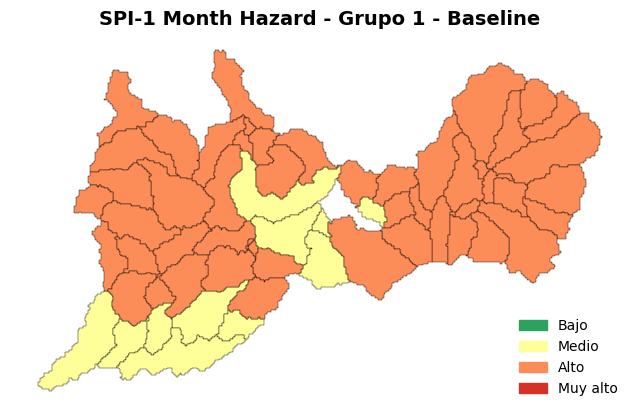

In [34]:
# Ejemplo SPI-1, escenario 1, cuenca "RioX"
plot_hazard_map(
    hazard_df=hazard_base_1,
    scn_id=1,
    basin_gdf=subbasins_gdf_g1,
    title="SPI-1 Month Hazard - Grupo 1 - Baseline"
)


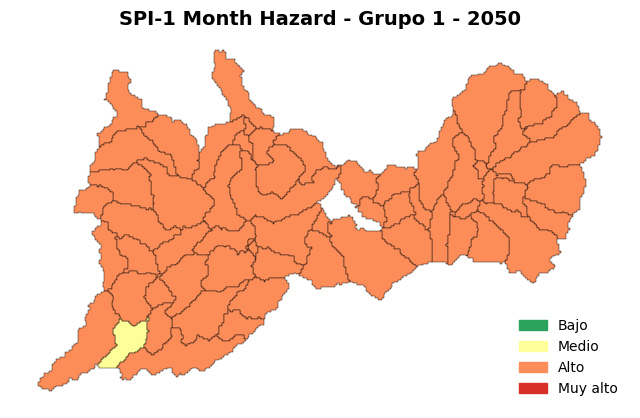

In [35]:
# Ejemplo SPI-1, escenario 1, cuenca "RioX"
plot_hazard_map(
    hazard_df=hazard_base_1,
    scn_id=2,
    basin_gdf=subbasins_gdf_g1,
    title="SPI-1 Month Hazard - Grupo 1 - 2050"
)


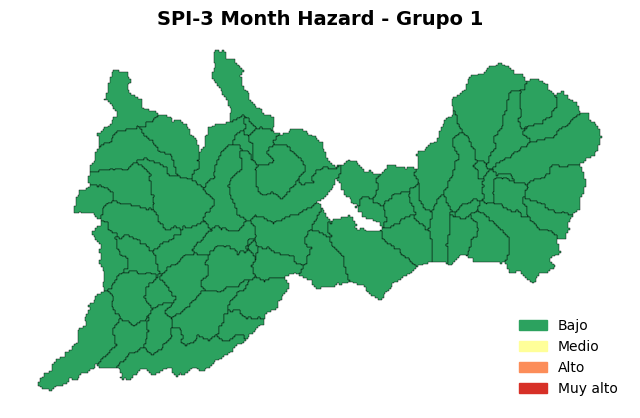

In [36]:
# Ejemplo SPI-3, escenario 1, cuenca "RioX"
plot_hazard_map(
    hazard_df=hazard_base_3,
    scn_id=1,
    basin_gdf=subbasins_gdf_g1,
    title="SPI-3 Month Hazard - Grupo 1"
)

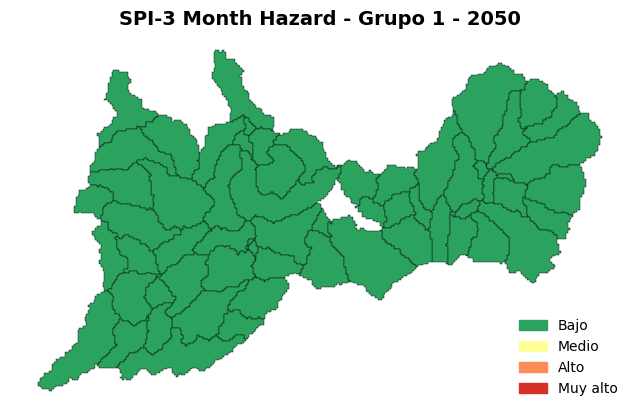

In [37]:
# Ejemplo SPI-3, escenario 1, cuenca "RioX"
plot_hazard_map(
    hazard_df=hazard_base_3,
    scn_id=2,
    basin_gdf=subbasins_gdf_g1,
    title="SPI-3 Month Hazard - Grupo 1 - 2050"
)

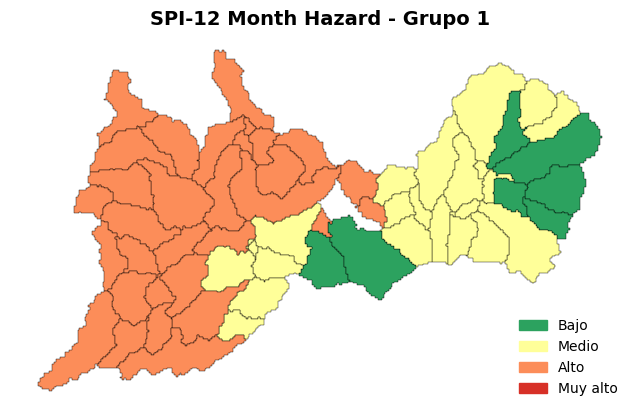

In [38]:
# Ejemplo SPI-12, escenario 1, cuenca "RioX"
plot_hazard_map(
    hazard_df=hazard_base_12,
    scn_id=1,
    basin_gdf=subbasins_gdf_g1,
    title="SPI-12 Month Hazard - Grupo 1"
)

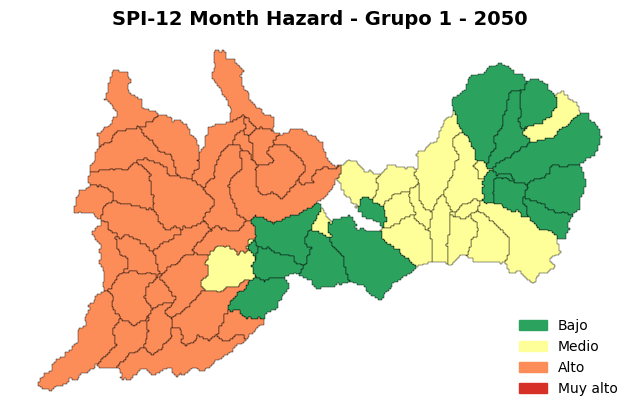

In [39]:
# Ejemplo SPI-12, escenario 1, cuenca "RioX"
plot_hazard_map(
    hazard_df=hazard_base_12,
    scn_id=2,
    basin_gdf=subbasins_gdf_g1,
    title="SPI-12 Month Hazard - Grupo 1 - 2050"
)

In [40]:
# Insert to the BD SPI_X (in this case SPI_12 - annual)
hazard_base = hazard_base_12.copy()

In [42]:
#insert the results into the sqlite database
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

rows_to_insert = []

for _, row in hazard_base.iterrows():
    rows_to_insert.append((
        int(row['ScnID']),
        IndID,
        int(row['comid']),
        int(row['Hazard_value'])
    ))

insert_query = """
INSERT OR REPLACE INTO IndValues_Dyn (ScnID, IndID, COMID, Value)
VALUES (?, ?, ?, ?);
"""

In [43]:
# check that the expected min and max values in the indicators table match the calculated values
indicator_limits = pd.read_sql_query(
    """
    SELECT IndID, Min, Max
    FROM Indicators
    WHERE IndID = ?
    """,
    conn,
    params=(IndID,)
)

if indicator_limits.empty:
    raise ValueError(f"No entry found in Indicators table for IndID = {IndID}")

ind_min = indicator_limits.loc[0, 'Min']
ind_max = indicator_limits.loc[0, 'Max']

print(f"Indicator {IndID}  Min: {ind_min}, Max: {ind_max}")

value_stats_by_scenario = (
    hazard_base
    .groupby('ScnID')['Hazard_value']
    .agg(['min', 'max', 'count'])
    .reset_index()
)

print("\n=== Value values by scenario ===")
print(value_stats_by_scenario)

df_check = pd.DataFrame(
    rows_to_insert,
    columns=['ScnID', 'IndID', 'COMID', 'Value']
)

duplicates = df_check.duplicated(subset=['ScnID', 'IndID', 'COMID'])

print("\nDuplicates in rows_to_insert:")
print(df_check[duplicates])

Indicator 101  Min: 1, Max: 4

=== Value values by scenario ===
   ScnID  min  max  count
0      1    1    4   3655
1      2    1    3   3054

Duplicates in rows_to_insert:
Empty DataFrame
Columns: [ScnID, IndID, COMID, Value]
Index: []


In [44]:
#Execute insert to SQLite Database
cursor.executemany(insert_query, rows_to_insert)
conn.commit()
conn.close()